# 🌊 HyFlood: Compound Flooding with SFINCS

Coastal flooding is rarely caused by a single driver. Along the Oregon coast, the
most damaging events combine **high sea levels**, **energetic waves** and
**intense rainfall**. When these drivers act together we speak of
**compound flooding**.

**HyFlood** is a hybrid framework to model compound flooding efficiently. It
follows the same philosophy we have already used with BinWaves and HySwash:

1. Sample the space of possible forcing conditions (**LHS**).
2. Select a small set of representative scenarios (**MDA**).
3. Simulate only those scenarios with a physics-based model (**SFINCS**).
4. Compress the results (**PCA**) so that a surrogate model can later
   reproduce the flood maps for *any* new combination of drivers.

In this notebook we put together **everything we have built so far** in the
course:

| Step | Tool | From → To |
|:-----|:-----|:----------|
| 1 | **BinWaves** | Offshore wave spectra → nearshore wave spectra |
| 2 | **HySwash** | Nearshore waves → wave setup and infragravity waves at the coast |
| 3 | **SFINCS** | Sea level + waves + rain → inland flood maps |

> **Inputs** (generated in previous notebooks):
> - BinWaves propagation coefficients: `additive/binwaves/outputs/kp_coefficients.nc`
> - HySwash surrogate models: `metamodel/hyswash/export/pca_model_*.pkl` and `rbf_spatial_model_*.pkl`
> - SFINCS model for Newport, OR (grid, bathymetry, mask and subgrid tables) in `templates/`
>
> **Outputs:**
> - One SFINCS simulation per representative scenario in `output/`
> - PCA model of the simulated flood maps in `export/pca_model.pkl`

**References:**
> * Leijnse et al. (2021). *Modeling compound flooding in coastal systems using a computationally efficient reduced-physics solver: Including fluvial, pluvial, tidal, wind- and wave-driven processes*. **Coastal Engineering**,
> [https://doi.org/10.1016/j.coastaleng.2020.103796](https://doi.org/10.1016/j.coastaleng.2020.103796)

> * Cagigal et al. (2024). *BinWaves: An additive hybrid method to downscale directional wave spectra to nearshore areas*. **Ocean Modelling**.

> * Ricondo et al. (2024). *HySwash: A hybrid model for nearshore wave processes*. **Ocean Engineering**,
> [https://doi.org/10.1016/j.oceaneng.2023.116419](https://doi.org/10.1016/j.oceaneng.2023.116419)

In [1]:
import os
import os.path as op

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import pyproj
import xarray as xr

In [2]:
root_dir = os.getcwd()

output_dir = op.join(root_dir, "output")
templates_dir = op.join(root_dir, "templates")
export_dir = op.join(root_dir, "export")
os.makedirs(export_dir, exist_ok=True)

# Outputs from the previous notebooks
binwaves_dir = op.join(root_dir, "..", "..", "additive", "binwaves")
export_dir_hyswash = op.join(root_dir, "..", "hyswash", "export")

## 1. Define compound flooding scenarios

Each HyFlood simulation is defined by a combination of **ocean** and
**precipitation** forcing conditions:

| Variable | Description | Range |
|:---------|:------------|:-----:|
| `Hs` | Offshore significant wave height | 0.5–3.0 m |
| `Tp` | Offshore peak period | 5–15 s |
| `Dir` | Offshore mean wave direction (coming from, nautical) | 180–330° |
| `SL` | Still sea level (tide + storm surge) | −0.5–2.5 m |
| `precipitation` | Total rainfall depth of the storm | 0–80 mm |
| `precip_duration` | Rainfall duration | 1–25 h |

For simplicity, we assume that the **rainfall peak coincides with the wave
and sea-level peak**, i.e. the worst-case timing of the drivers.

In [3]:
variables_bounds = {
    # Ocean forcing
    "Hs": (0.5, 3.0),               # [m]
    "Tp": (5.0, 15.0),              # [s]
    "Dir": (180.0, 330.0),          # [deg]
    "SL": (-0.5, 2.5),              # [m]
    # Precipitation forcing
    "precipitation": (0.0, 80.0),   # [mm]
    "precip_duration": (1.0, 25.0), # [h]
}

### 1.1. Latin Hypercube Sampling (LHS)

As in HySwash, we use **LHS** to generate 10,000 combinations of the input
variables that cover the whole parameter space uniformly.

In [4]:
from bluemath_tk.datamining.lhs import LHS

lhs = LHS(num_dimensions=len(variables_bounds))

df_dataset = lhs.generate(
    dimensions_names=list(variables_bounds.keys()),
    lower_bounds=[bounds[0] for bounds in variables_bounds.values()],
    upper_bounds=[bounds[1] for bounds in variables_bounds.values()],
    num_samples=10_000,
)

df_dataset

,Hs,Tp,Dir,SL,precipitation,precip_duration
0,2.295622,5.084050,289.467838,1.950415,55.309505,21.871784
1,1.008543,11.789591,276.426756,1.494392,7.921972,10.053908
2,1.459668,9.238212,208.420452,1.075464,16.286928,8.009433
3,2.641199,6.425738,279.138745,0.225916,25.988118,11.221646
4,2.104010,13.874275,186.021882,0.600917,0.134715,11.987272
...,...,...,...,...,...,...
9995,0.718402,11.012851,329.127409,0.117260,32.019574,15.654140
9996,1.501831,10.705110,296.963189,1.023981,58.413797,5.603359
9997,2.614988,7.949978,199.735225,2.028581,69.623078,15.912980
9998,1.488148,7.554223,208.117957,1.689585,40.040085,18.269054


### 1.2. Maximum Dissimilarity Algorithm (MDA)

Running SFINCS for all 10,000 scenarios would be too expensive. The **MDA**
selects a small subset of scenarios that are as different as possible from
each other, so that they span the full range of conditions.

> ⏱️ For the course we only simulate **24 scenarios** so that everything runs in
> a few minutes. A real HyFlood application would use a few hundred.

In [5]:
from bluemath_tk.datamining.mda import MDA

mda_samples = 24

mda = MDA(num_centers=mda_samples)
mda.fit(data=df_dataset, normalize_data=True)

mda.centroids.round(2)

,Hs,Tp,Dir,SL,precipitation,precip_duration
0,2.72,13.24,306.46,1.58,79.41,22.46
1,0.69,5.97,186.50,0.08,1.34,4.10
2,2.82,8.00,193.06,2.45,0.06,24.72
3,0.62,14.92,327.03,0.28,1.89,23.76
4,0.51,14.44,197.37,2.49,62.86,7.44
5,2.75,6.25,320.94,2.12,22.84,1.19
6,2.90,14.95,240.34,-0.47,10.16,6.54
7,1.96,5.04,190.53,-0.22,78.43,22.73
8,0.91,7.59,329.93,-0.48,61.65,2.42
9,0.74,5.11,305.45,2.41,34.56,21.68


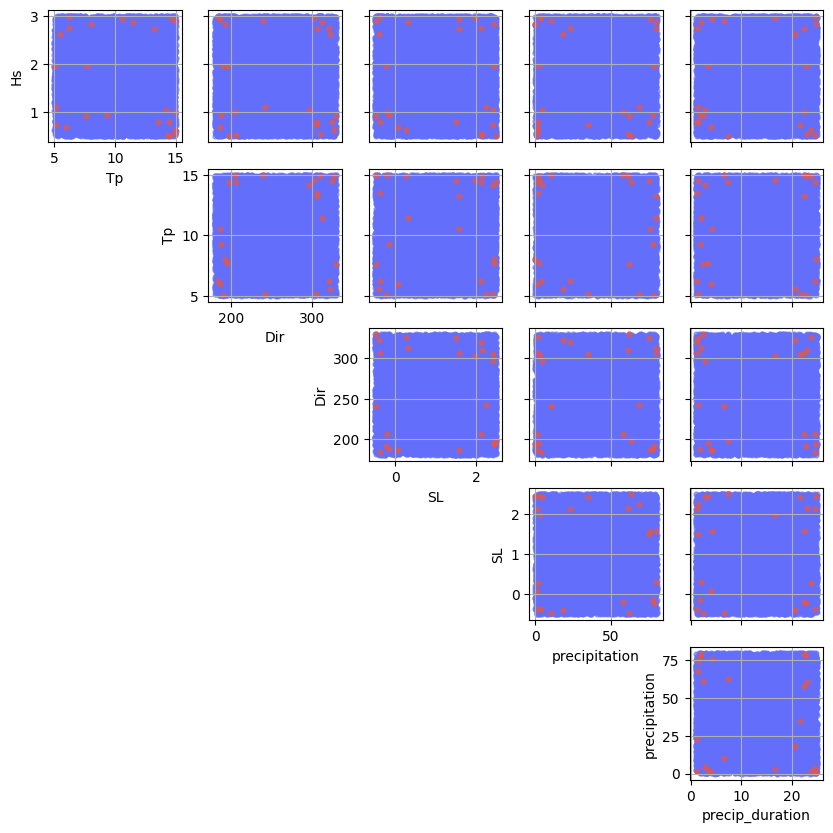

In [6]:
fig, axes = mda.plot_selected_centroids(
    s=12,
    data_color=px.colors.qualitative.Plotly[0],
    centroids_color=px.colors.qualitative.Plotly[1],
)

fig.set_size_inches(10, 10)
plt.show()

## 2. Offshore → nearshore waves with BinWaves

The wave conditions above are defined **offshore**. Before they reach Newport,
waves are transformed by refraction, shoaling and sheltering over the
continental shelf.

In the BinWaves notebooks we pre-computed, for every output site, the
propagation coefficients $K_p(f, \theta)$ of every monochromatic wave component.
Now we can reuse them: any offshore spectrum can be propagated to the coast
simply by multiplying it by $K_p$ (no new SWAN runs needed!).

In [7]:
kp_coeffs = xr.open_dataset(op.join(binwaves_dir, "outputs", "kp_coefficients.nc"))
kp_coeffs

<xarray.Dataset> Size: 54MB
Dimensions:   (case_num: 348, site: 56, freq: 29, dir: 12)
Coordinates:
  * case_num  (case_num) int64 3kB 0 1 2 3 4 5 6 ... 341 342 343 344 345 346 347
  * site      (site) int64 448B 0 1 2 3 4 5 6 7 8 ... 47 48 49 50 51 52 53 54 55
  * freq      (freq) float64 232B 0.035 0.0385 0.0423 ... 0.4135 0.4547 0.5
  * dir       (dir) float64 96B 15.0 45.0 75.0 105.0 ... 255.0 285.0 315.0 345.0
    lat       (site) float64 448B ...
    lon       (site) float64 448B ...
    coord_x   (site) float64 448B ...
    coord_y   (site) float64 448B ...
Data variables:
    kps       (case_num, site, freq, dir) float64 54MB ...

### 2.1. Select the BinWaves site closest to Newport

We only need the nearshore waves at the point where SFINCS receives its
water-level boundary condition. We therefore select the BinWaves output site
closest to that point.

In [8]:
# SFINCS offshore boundary point (UTM zone 10N)
boundary_point = {"x": 412500.0, "y": 4939800.0, "epsg": 32610}

to_utm = pyproj.Transformer.from_crs(4326, boundary_point["epsg"], always_xy=True)
sites_x, sites_y = to_utm.transform(kp_coeffs["lon"].values, kp_coeffs["lat"].values)

distance_km = np.hypot(sites_x - boundary_point["x"], sites_y - boundary_point["y"]) / 1000
site_id = int(kp_coeffs["site"].values[np.argmin(distance_km)])

print(
    f"Selected BinWaves site: {site_id} "
    f"({kp_coeffs['lon'].sel(site=site_id).item():.3f}°E, "
    f"{kp_coeffs['lat'].sel(site=site_id).item():.3f}°N), "
    f"{distance_km.min():.1f} km from the SFINCS boundary"
)

Selected BinWaves site: 34 (-124.146°E, 44.571°N), 5.2 km from the SFINCS boundary


### 2.2. Build the offshore spectra

For each MDA scenario we build a parametric directional spectrum from `Hs`,
`Tp` and `Dir`:

- **Frequency:** TMA spectrum (JONSWAP corrected for finite depth).
- **Direction:** Cartwright ($\cos^{2s}$) spreading with a directional spread of 15°.

The spectra are built on the same frequency/direction grid as the $K_p$
coefficients.

In [9]:
from wavespectra.construct import construct_partition

offshore_spectra = xr.concat(
    [
        construct_partition(
            freq_name="tma",
            freq_kwargs={
                "freq": kp_coeffs["freq"],
                "fp": 1 / case["Tp"],
                "dep": 100,
                "hs": case["Hs"],
            },
            dir_name="cartwright",
            dir_kwargs={
                "dir": kp_coeffs["dir"],
                "dm": case["Dir"],
                "dspr": 15,
            },
        ).expand_dims(time=[case_id])
        for case_id, case in mda.centroids.iterrows()
    ],
    dim="time",
)

### 2.3. Propagate the spectra to the coast

In [10]:
from bluemath_tk.waves.binwaves import reconstruc_spectra

nearshore_spectra = reconstruc_spectra(
    offshore_spectra=offshore_spectra,
    kp_coeffs=kp_coeffs.sel(site=[site_id]),
    num_workers=1,
    memory_limit=0.9,
).isel(site=0)

nearshore_stats = (
    nearshore_spectra.rename({"kps": "efth"})
    .spec.stats(["hs", "tp", "dp"])
    .to_dataframe()[["hs", "tp", "dp"]]
)

Let's compare the offshore and nearshore wave parameters. Depending on the
incoming direction and period, waves are amplified by shoaling or attenuated
by refraction, and their direction turns towards the coast.

> ℹ️ The nearshore direction is the **peak** direction of the reconstructed
> spectrum, so it takes the discrete values of the BinWaves directional bins.

In [11]:
df_waves = pd.DataFrame(
    {
        "Hs offshore [m]": mda.centroids["Hs"].values,
        "Hs nearshore [m]": nearshore_stats["hs"].values,
        "Tp offshore [s]": mda.centroids["Tp"].values,
        "Tp nearshore [s]": nearshore_stats["tp"].values,
        "Dir offshore [°]": mda.centroids["Dir"].values,
        "Dir nearshore [°]": nearshore_stats["dp"].values,
    },
    index=pd.Index(mda.centroids.index, name="case"),
)

df_waves.round(2)

,Hs offshore [m],Hs nearshore [m],Tp offshore [s],Tp nearshore [s],Dir offshore [°],Dir nearshore [°]
case,,,,,,
0,2.72,2.74,13.24,13.14,306.46,315.0
1,0.69,0.55,5.97,6.14,186.50,195.0
2,2.82,2.61,8.00,8.04,193.06,195.0
3,0.62,0.69,14.92,14.61,327.03,345.0
4,0.51,0.51,14.44,14.36,197.37,195.0
5,2.75,2.92,6.25,6.20,320.94,315.0
6,2.90,2.88,14.95,14.63,240.34,255.0
7,1.96,1.66,5.04,4.67,190.53,195.0
8,0.91,1.03,7.59,7.51,329.93,345.0


## 3. Nearshore waves → coastal water levels with HySwash

SFINCS does not resolve individual waves. Instead, waves enter the model
through their effect on the water level at the boundary:

- **Wave setup** (`Msetup`): the mean increase in water level caused by wave
  breaking. It varies slowly in time.
- **Infragravity waves** (`ig`): long waves (periods of minutes) that are
  generated in the surf zone and can propagate far inland.

We obtain both from the **HySwash surrogate models** trained in the previous
notebooks, which take as inputs the nearshore `Hs`, the wave steepness
$H_s/L_0$ (with $L_0 = gT_p^2 / 2\pi \approx 1.56\,T_p^2$) and the water
level `WL`.

In [12]:
df_hyswash = pd.DataFrame(
    {
        "Hs": nearshore_stats["hs"].values,
        "Hs_L0": nearshore_stats["hs"].values / (1.56 * nearshore_stats["tp"].values ** 2),
        "WL": mda.centroids["SL"].values,
    },
    index=mda.centroids.index,
)

> ⚠️ **Stay within the training range!**
>
> A surrogate model is only reliable inside the parameter space it was trained
> on. HySwash was trained with the same water-level range as our scenarios
> (−0.5 to 2.5 m), but some nearshore sea states may still fall outside its
> training range (e.g. very steep waves, with large `Hs_L0`). To be safe, we
> clip the inputs to the HySwash training range before predicting.

In [13]:
hyswash_training = pd.read_pickle(op.join(export_dir_hyswash, "lhs_dataset.pkl"))

df_hyswash_clipped = df_hyswash.clip(
    lower=hyswash_training[df_hyswash.columns].min(),
    upper=hyswash_training[df_hyswash.columns].max(),
    axis=1,
)

HySwash predicts the full cross-shore profile of each variable. We take the
values at a nearshore location of the profile (`Xp = 900` m, just seaward of
the shoreline), which we use as the wave contribution at the SFINCS boundary.

In [14]:
import logging

from bluemath_tk.core.io import load_model

logging.getLogger("RBF").setLevel(logging.WARNING)

xp_boundary = 900
hyswash_vars = ["Msetup", "ig"]

for var in hyswash_vars:
    pca_model = load_model(op.join(export_dir_hyswash, f"pca_model_{var}.pkl"))
    rbf_model = load_model(op.join(export_dir_hyswash, f"rbf_spatial_model_{var}.pkl"))

    # offshore conditions → RBF → PCs → inverse PCA → cross-shore profile
    pcs = rbf_model.predict(df_hyswash_clipped[["Hs", "Hs_L0", "WL"]])
    pcs = xr.DataArray(
        pcs.values,
        dims=[pca_model.pca_dim_for_rows, "PCs"],
        coords={
            pca_model.pca_dim_for_rows: pcs.index.values,
            "PCs": pcs.columns.values,
        },
    )
    profile = pca_model.inverse_transform(pcs)[var]

    df_hyswash[var] = profile.sel(Xp=xp_boundary).values

df_hyswash.round(3)

INFO:PCA:Inverse transforming data using PCA model
INFO:PCA:Inverse transforming data using PCA model


,Hs,Hs_L0,WL,Msetup,ig
0,2.741,0.010,1.577,0.273,0.580
1,0.549,0.009,0.082,-0.025,0.056
2,2.609,0.026,2.447,0.185,0.488
3,0.687,0.002,0.275,0.029,0.110
4,0.509,0.002,2.489,-0.155,-0.081
5,2.917,0.049,2.121,0.261,0.596
6,2.879,0.009,-0.473,0.448,0.756
7,1.657,0.049,-0.219,0.196,0.387
8,1.029,0.012,-0.479,0.098,0.225
9,0.742,0.018,2.407,-0.154,-0.040


> ⚠️ Our HySwash surrogate was trained with only 10 SWASH simulations, so for
> some conditions it can return small **unphysical negative values** (e.g. a
> negative infragravity wave height). We set them to zero before building the
> SFINCS forcing. With more training simulations this would not be needed.

In [15]:
df_hyswash[hyswash_vars] = df_hyswash[hyswash_vars].clip(lower=0)

## 4. Build the SFINCS forcing

We now have all the ingredients to build the SFINCS boundary conditions for
each scenario. SFINCS receives two water-level signals at the boundary point
and a rainfall time series over the whole domain:

| SFINCS file | Signal | Built from |
|:------------|:-------|:-----------|
| `sfincs.bzs` | Slowly varying water level | `SL` + `Msetup` |
| `sfincs.bzi` | Infragravity waves | `ig`, as a harmonic signal with a 200 s period |
| `sfincs.precip` | Rainfall intensity | Triangular hyetograph from `precipitation` and `precip_duration` |

The **rainfall peak** occurs at hour 12 of the simulation. For simplicity,
the sea level, wave setup and infragravity height are kept constant during the
storm.

> ℹ️ In the figure below, the thick sea-level band is the infragravity
> oscillation: a 200 s period signal is too fast to be resolved on a 27 h axis.

In [16]:
from utils.forcing import build_precipitation_forcings, build_waterlevel_forcings

sfincs_ref = "2000-01-01 00:00:00"

# Simulation window [h], long enough to contain every rainfall event
time_hours = np.arange(-1, 26)
n_times = len(time_hours)

slowly_waterlevel_forcing, quickly_waterlevel_forcing = build_waterlevel_forcings(
    msetup=[np.full(n_times, value) for value in df_hyswash["Msetup"]],
    h_ig=[np.full(n_times, value) for value in df_hyswash["ig"]],
    msl=mda.centroids["SL"].values,
    time=time_hours,
    reference_time=sfincs_ref,
)

precipitation_forcing = build_precipitation_forcings(
    mda.centroids,
    reference_time=sfincs_ref,
)

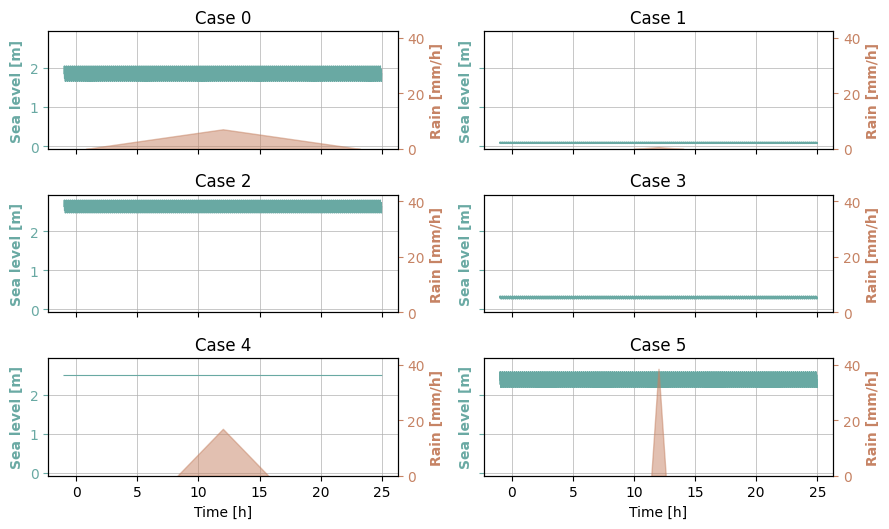

In [17]:
from utils.plotting import plot_sfincs_forcings

# Plot the forcing of the first cases
cases_to_plot = slice(0, 6)

fig, axes = plot_sfincs_forcings(
    slowly_waterlevel_forcing[cases_to_plot],
    quickly_waterlevel_forcing[cases_to_plot],
    precipitation_forcing[cases_to_plot],
    reference_time=sfincs_ref,
)
plt.show()

## 5. Numerical model: SFINCS

**SFINCS** (Super-Fast INundation of CoastS) is a reduced-physics model
developed by Deltares that solves the shallow-water equations without the
advection terms. Combined with **subgrid** bathymetry, it simulates flooding
over large areas in seconds to minutes, which makes it ideal for running
many scenarios.

For a detailed description of the model, see the
[SFINCS documentation](https://sfincs.readthedocs.io).

### 5.1. Model setup

The spatial configuration of SFINCS is **the same for all simulations**, while
the forcing built above changes for each scenario:

- a 200 m regular grid covering Newport and the Yaquina Bay,
- a subgrid table built from a high-resolution DEM (`sfincs_subgrid.nc`),
- the active and boundary masks (`sfincs.msk`, `sfincs.ind`).

In [18]:
gdf_boundary_points = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([boundary_point["x"]], [boundary_point["y"]]),
    crs=boundary_point["epsg"],
)

fixed_parameters = {
    "x0": 413000.0,
    "y0": 4933400.0,
    "dx": 200.0,
    "dy": 200.0,
    "rotation": 0,
    "nmax": 62,
    "mmax": 79,
    "epsg": boundary_point["epsg"],
    "gdf_boundary_points": gdf_boundary_points,
}

metamodel_parameters = {
    "slowly_waterlevel_forcing": slowly_waterlevel_forcing,
    "quickly_waterlevel_forcing": quickly_waterlevel_forcing,
    "precipitation_forcing": precipitation_forcing,
}

### 5.2. Build and run the SFINCS cases

As with SWASH, the `SfincsModelWrapper` writes one folder per scenario in
`output/` and launches the simulations:

**build the cases → launch the simulations → postprocess**

> ⏱️ Each simulation takes 10–30 seconds (a few minutes for all the cases).
> If you have already run the cases, set `run_sfincs = False` to skip this step.

In [19]:
from utils.sfincs_wrapper import SfincsModelWrapper

sfincs_wrapper = SfincsModelWrapper(
    templates_dir=templates_dir,
    templates_name=[
        "sfincs.ind",
        "sfincs.dep",
        "sfincs.msk",
        "sfincs_subgrid.nc",
    ],
    metamodel_parameters=metamodel_parameters,
    fixed_parameters=fixed_parameters,
    output_dir=output_dir,
    debug=False,
)

2026-09-29 20:44:49,512 - SfincsModelWrapper - WARNING - Parameter slowly_waterlevel_forcing is not in the default_parameters
2026-09-29 20:44:49,513 - SfincsModelWrapper - WARNING - Parameter quickly_waterlevel_forcing is not in the default_parameters
2026-09-29 20:44:49,513 - SfincsModelWrapper - WARNING - Parameter precipitation_forcing is not in the default_parameters


In [20]:
run_sfincs = True

if run_sfincs:
    sfincs_wrapper.build_cases()
    sfincs_wrapper.run_cases(launcher="serial", num_workers=2)

INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Write forcing files
INFO:hydromt_sfincs.sfincs:Write vector file(s) for forcing.bzs to 'gis' subfolder
INFO:pyogrio._io:Created 1 records
INFO:hydromt_sfincs.sfincs:Write forcing files
INFO:hydromt_sfincs.sfincs:Write vector file(s) for forcing.bzs to 'gis' subfolder
INFO:pyogrio._io:Created 1 records
INFO:hydromt_sfincs.sfincs:Reading data catalog artifact_data latest
INFO:hydromt_sfincs.sfincs:Parsing data catalog from /root/.hydromt_data/artifact_data/v0.0.9/data_catalog.yml
INFO:hydromt_sfincs.sfincs:Reading  csv data from /workspaces/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyflood/output/0000/_precipitation_forcing.csv
INFO:hydromt_sfincs.sfincs:Writing model data to /workspaces/BlueMath_Course_Corvallis/methods/hybrid_downscaling/metamodel/hyflood/output/0000
INFO:hydromt_sfincs.sfincs:Write forcing files
INFO:hydromt_sfincs.sfincs:Write vector file

## 6. Postprocess the flood maps

SFINCS computes the maximum water level (`zsmax`) on its 200 m grid. Thanks to
the subgrid approach, we can **downscale** it to the resolution of the
high-resolution DEM, and subtract the terrain to obtain the maximum
**flood depth**.

Areas below the Mean Higher High Water (`MHHW`) level are considered
permanently wet and are masked out.

In [21]:
from utils.postprocessing import postprocess_cases

dem_path = op.join(templates_dir, "Newport_UTM.tif")

output = postprocess_cases(
    cases_dir=output_dir,
    dep_path=dem_path,
    mhhw=0.2,
    n_cases=mda_samples,
)

INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO:hydromt_sfincs.sfincs:Initializing sfincs model from hydromt_sfincs (v1.2.2).
INFO

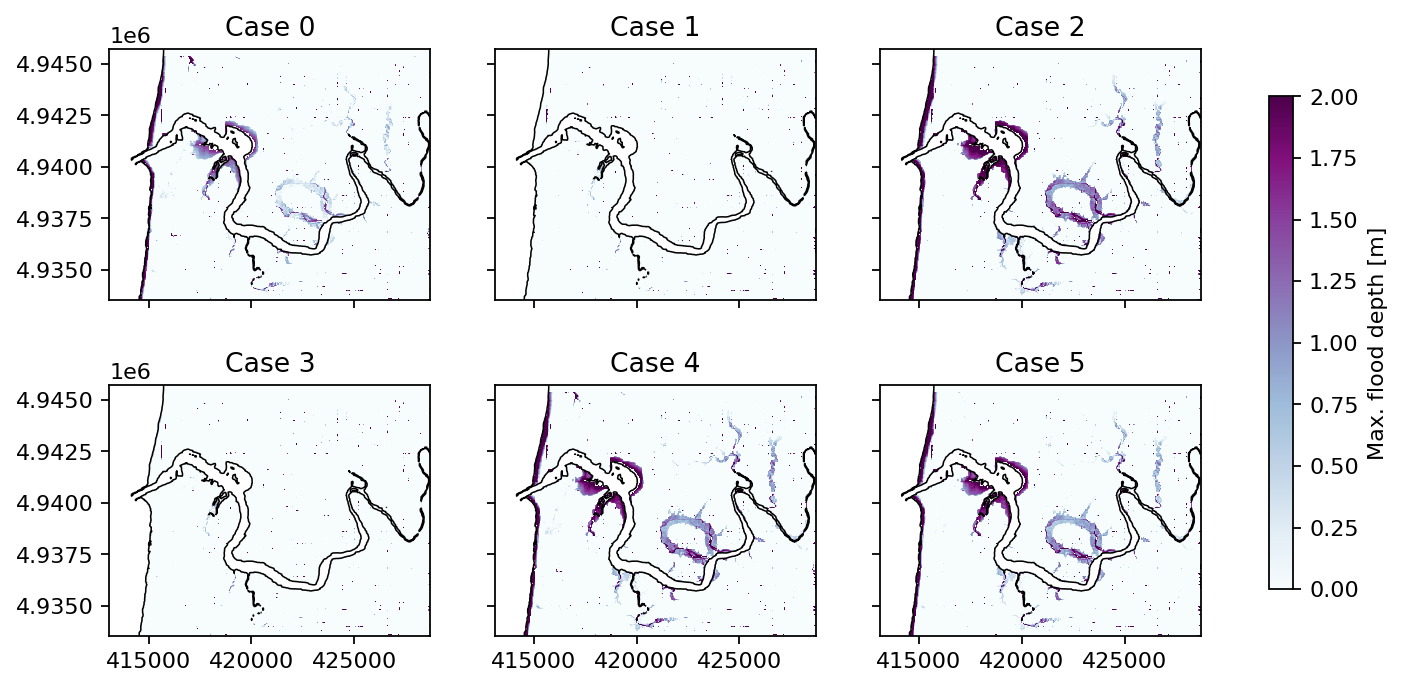

In [22]:
from utils.plotting import plot_output_cases

dep_hr = xr.open_dataset(dem_path)

fig, axes = plot_output_cases(
    output[cases_to_plot],
    dep_hr,
    cmap="BuPu",
    vmin=0,
    vmax=2,
)
plt.show()

> 💬 **Discussion:** Compare the flood maps with the forcing of each case. Which
> driver dominates the flooding in each scenario: sea level, waves or rain?

## 7. Dimensionality reduction with PCA

Each flood map contains tens of thousands of pixels. As we did in HySwash,
instead of building a surrogate model for every pixel, we use **Principal
Component Analysis (PCA)** to describe the maps with a few spatial patterns
(**EOFs**) and their weights in each simulation (**PCs**).

We keep as many components as needed to explain **99.9% of the variance**.

In [23]:
from bluemath_tk.datamining.pca import PCA

var_to_predict = "zsmax"

output_dataset = xr.concat(output, dim="case_num")

pca = PCA(n_components=0.999)

pca.fit_transform(
    data=output_dataset,
    vars_to_stack=[var_to_predict],
    coords_to_stack=["x", "y"],
    pca_dim_for_rows="case_num",
    value_to_replace_nans={var_to_predict: 0.0},
)

pca.save_model(model_path=op.join(export_dir, "pca_model.pkl"))

INFO:PCA:Changing variable OMP_NUM_THREADS from 1 to 1. 
And setting self.num_workers to 1. 
To avoid conflicts with BlueMath parallel processing.
INFO:PCA:Number of processors requested leaves less than 2 processors available
INFO:PCA:
        -------------------------------------------------------------------
        | Initializing PCA reduction model with the following parameters:
        |    - n_components: 0.999
        |    - is_incremental: False
        | For more information, please refer to the documentation.
        -------------------------------------------------------------------
        
INFO:PCA:Explained variance ratio: 0.999
INFO:PCA:Using PCA
INFO:PCA:Adding windows in PCA dimension for rows
INFO:PCA:Generating stacked data matrix
INFO:PCA:Generating data matrix with variables to stack: ['zsmax'] and coordinates to stack: ['x', 'y']
If this is originated by using few times, please check 'nan_threshold_to_drop' parameter in fit method
INFO:PCA:Data matrix generated s

We also export the forcing conditions of the simulated scenarios (the MDA
centroids) and the full LHS dataset. Together with the PCA model, they are the
training data of the HyFlood surrogate model in the next notebook.

In [24]:
mda.centroids.to_pickle(op.join(export_dir, "mda_centroids.pkl"))
df_dataset.to_pickle(op.join(export_dir, "lhs_dataset.pkl"))

### 7.1. Spatial patterns and principal components

Each row shows one EOF (left), the dominant spatial pattern of flooding, and
its PC (right), which indicates how strongly that pattern is present in each
simulated scenario. We show the first 4 components.

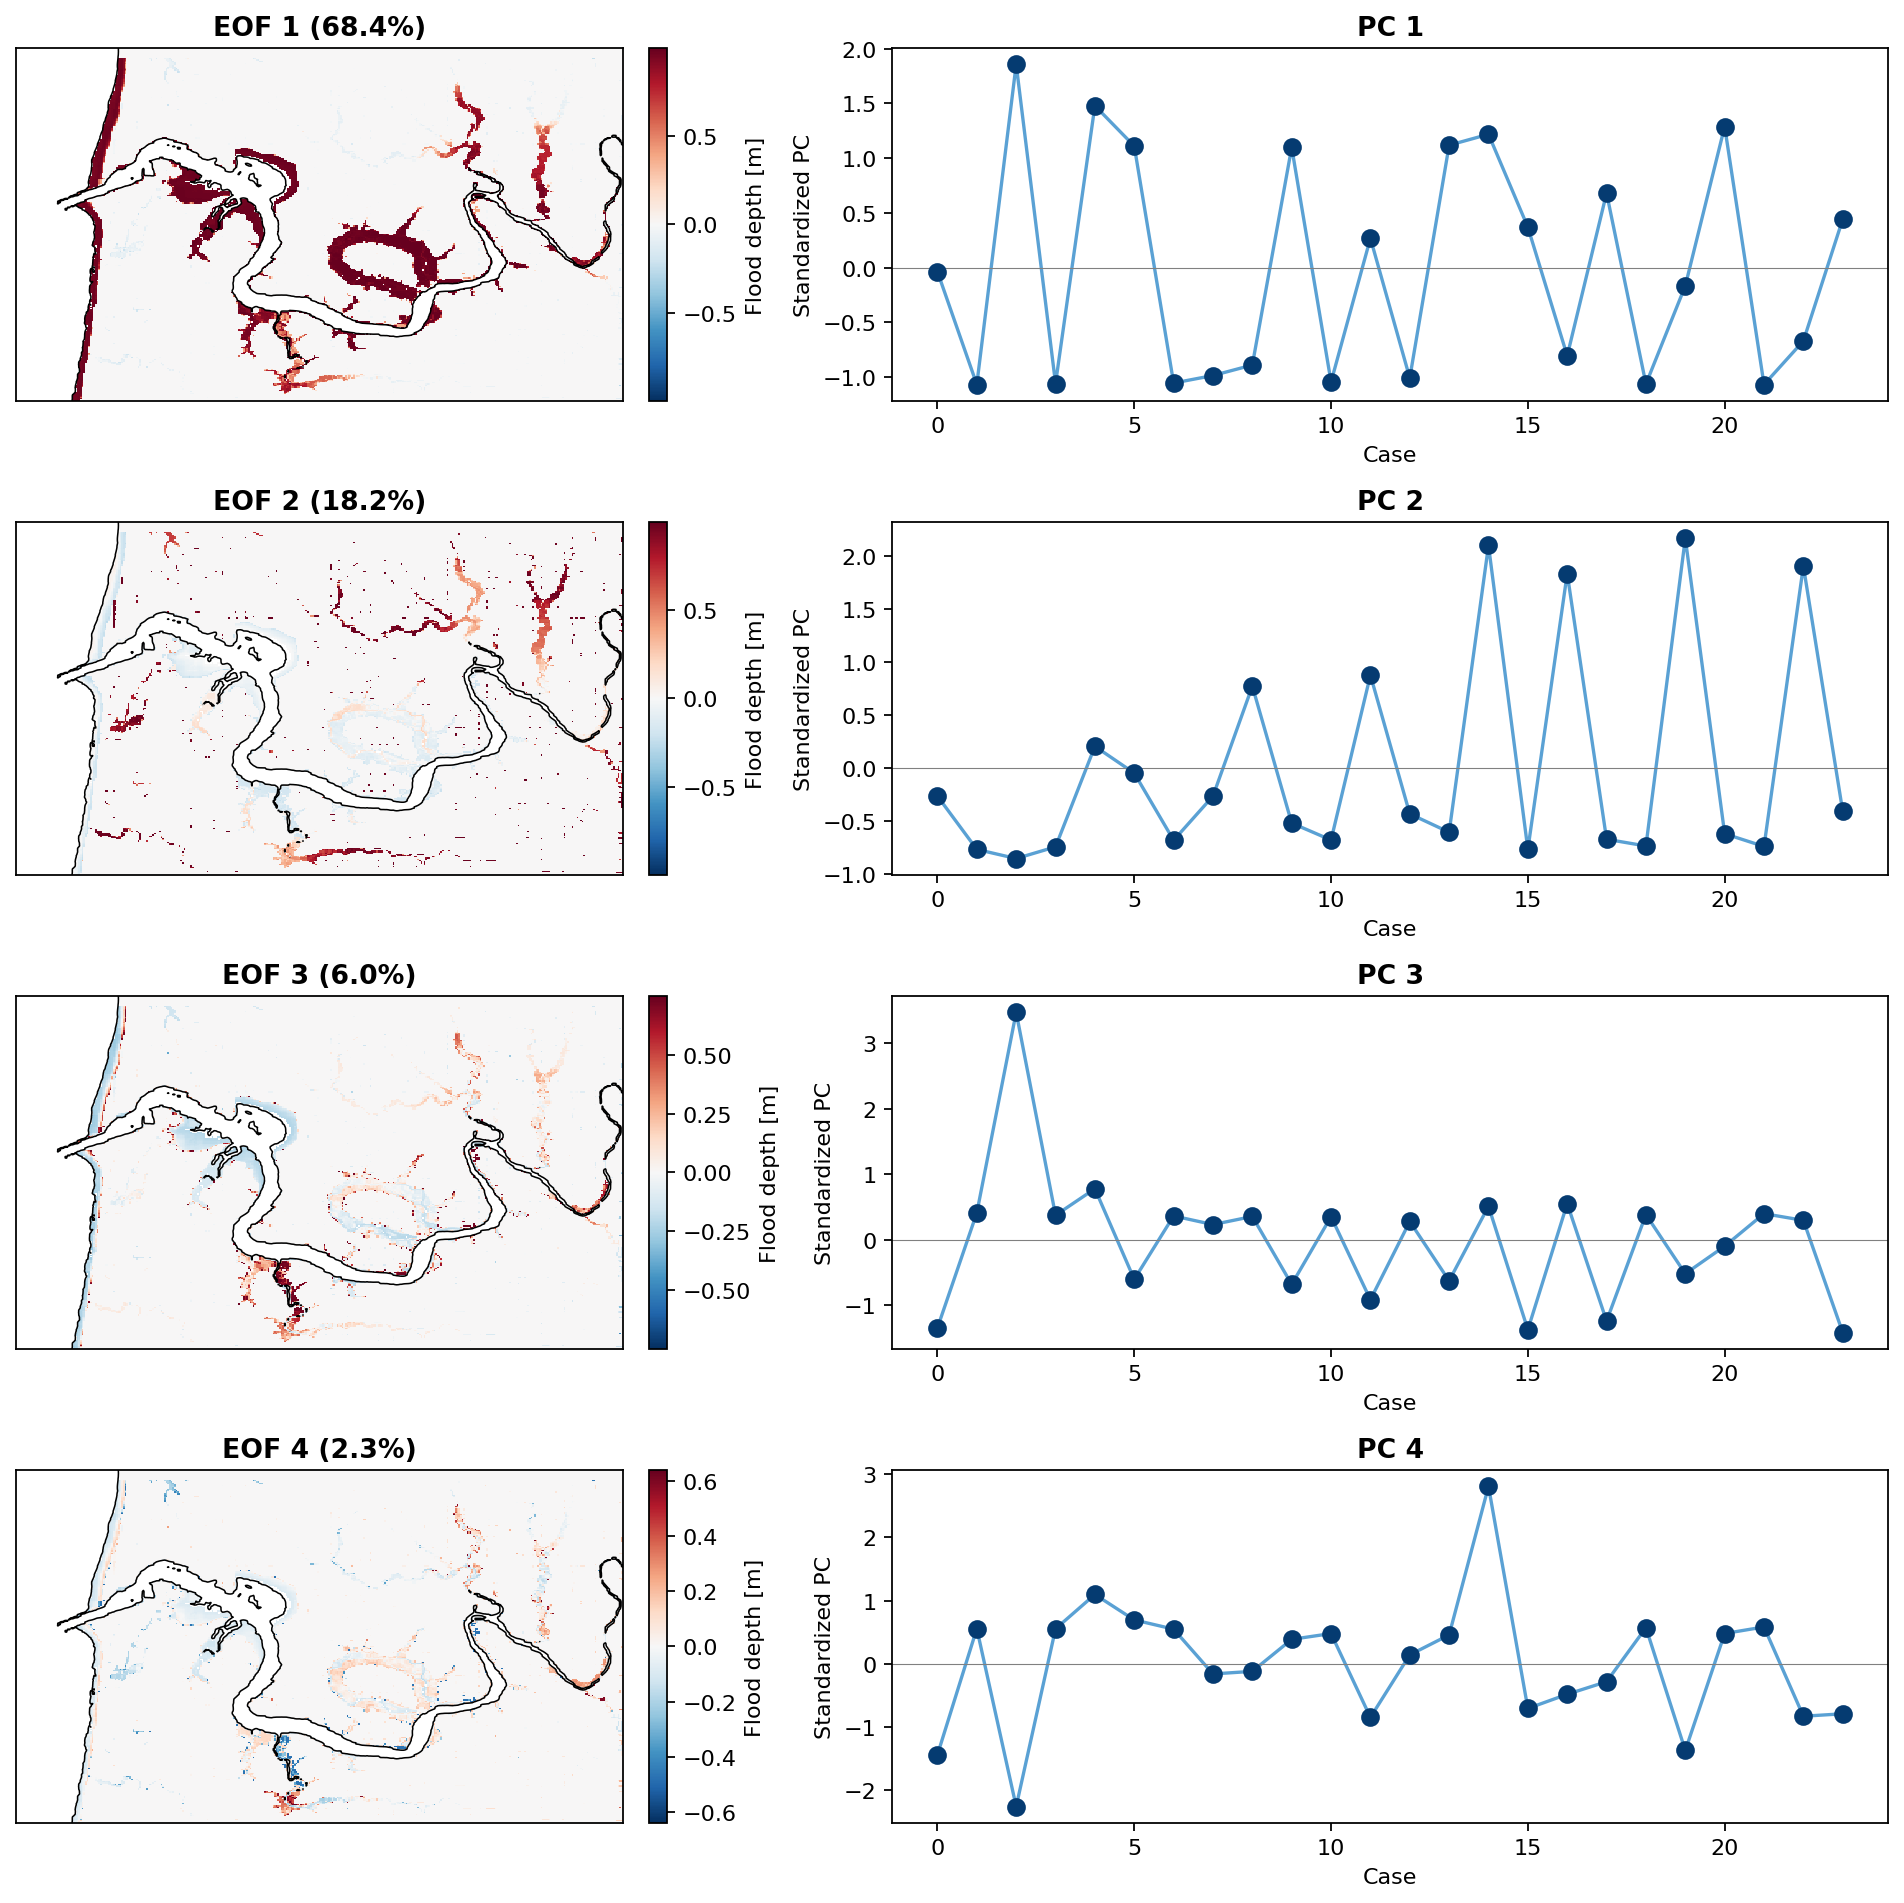

In [25]:
from utils.plotting import plot_pca_eofs_pcs

fig, axs = plot_pca_eofs_pcs(
    pca,
    dep_hr,
    var_to_predict,
    n_components=4,
    dpi=160,
)
plt.show()

## Summary

In this notebook, we:

- Defined compound flooding scenarios combining **waves, sea level and rain**,
  and selected a representative subset with **LHS + MDA**.
- Propagated the offshore wave spectra to Newport with the **BinWaves**
  coefficients.
- Estimated the **wave setup** and **infragravity waves** at the coast with the
  **HySwash** surrogate models.
- Built the forcing and ran **SFINCS** to obtain the flood maps of each scenario.
- Reduced the flood maps to a few spatial patterns with **PCA**.

## What's next?

With the PCA model, the only missing piece is a model that relates the forcing
conditions to the PCs. In the next notebook (`02_Reconstruction.ipynb`) we
will train a **Gaussian Process Regression (GPR)** for this purpose. Once
trained, HyFlood can produce a flood map, and its uncertainty, for **any
combination of waves, sea level and rain** in a fraction of a second, allowing
us to evaluate, for example, the effect of **sea level rise**.